# 2. Inference: baseline vs. simplified HAVI-Methyl

Walks through Sec. 11.1 — fit the FinaleMe-style classifier baseline, then the simplified HAVI-Methyl SVI loop, and compare per-CpG beta recovery.

All numbers come from `havi_methyl.run_one_coverage`; the same code paths drive the figure scripts in `scripts/`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np
import matplotlib.pyplot as plt
import havi_methyl as hm

In [2]:
rng = np.random.default_rng(20260429)
result, sim = hm.run_one_coverage(S=8, L=200, coverage=5.0, rng=rng, n_iter=10)
print('FinaleMe baseline r=', round(result.baseline['pearson'], 3),
      'RMSE=', round(result.baseline['rmse'], 3))
print('HAVI-Methyl     r=', round(result.havi['pearson'], 3),
      'RMSE=', round(result.havi['rmse'], 3))

FinaleMe baseline r= 0.809 RMSE= 0.186
HAVI-Methyl     r= 0.893 RMSE= 0.145


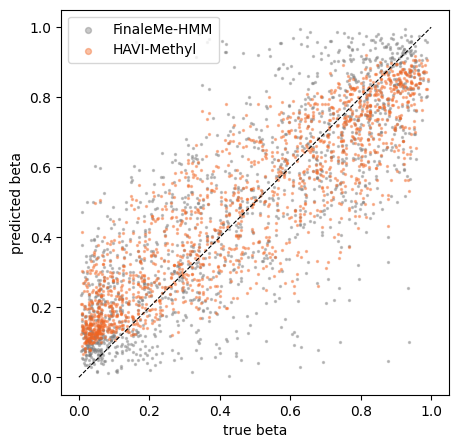

In [3]:
plt.figure(figsize=(5, 5))
plt.scatter(result.plot_data['true'], result.plot_data['pred_b'], s=2, alpha=0.4, label='FinaleMe-HMM', color='#7A7A7A')
plt.scatter(result.plot_data['true'], result.plot_data['pred_h'], s=2, alpha=0.4, label='HAVI-Methyl', color='#F26522')
plt.plot([0,1], [0,1], 'k--', lw=0.8)
plt.legend(markerscale=3); plt.xlabel('true beta'); plt.ylabel('predicted beta');

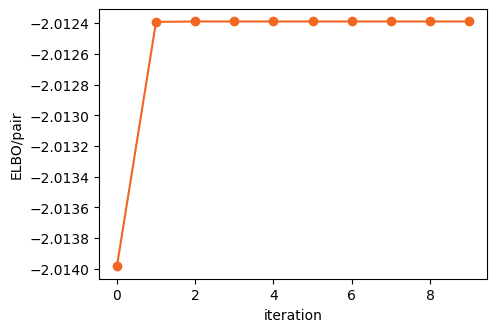

In [4]:
plt.figure(figsize=(5, 3.5))
plt.plot(result.plot_data['elbo_history'], '-o', color='#F26522'); plt.xlabel('iteration'); plt.ylabel('ELBO/pair');